In [704]:
import numpy
import pandas

from matplotlib import pyplot
import seaborn

def estres_empleado(carga, salario):
    efecto_carga = numpy.random.normal(0, 2)
    efecto_salario = numpy.random.normal(0, 3_000)
    efecto_bias = numpy.random.normal(0, 
        (abs(efecto_carga) / 10 + 
        abs(efecto_salario) / 15_000) / 2
    )

    return (
        (1 - efecto_bias) +
        (carga - efecto_carga) / 10 -
        (salario - efecto_salario) / 15_000
    )

for i in range(10):
    carga = int(numpy.random.normal(10, 1))
    salario = numpy.round(numpy.random.normal(15_000, 1_000), 2)
    estres = estres_empleado(carga, salario)
    print(
        f"Empleado {i + 1:2d}: "
        f"{carga:2d}h "
        f"${salario:9.2f} "
        f"{estres:4.2f}"
    )

Empleado  1:  7h $ 15032.61 0.21
Empleado  2:  8h $ 16216.81 0.33
Empleado  3:  9h $ 15034.38 1.01
Empleado  4:  9h $ 15329.17 0.92
Empleado  5: 10h $ 15456.23 0.99
Empleado  6:  9h $ 12605.80 0.50
Empleado  7:  8h $ 13933.96 0.88
Empleado  8: 10h $ 16328.66 0.99
Empleado  9: 10h $ 14731.78 0.55
Empleado 10: 10h $ 14530.23 1.29


In [567]:
n = 1_000

cargas = numpy.random.normal(10, 3, n).astype(int)
salarios = numpy.random.normal(15_000, 5_000, n).round(2)
estreses = pandas.Series(zip(cargas, salarios)).map(lambda t: estres_empleado(t[0], t[1])).round(2)

pandas.DataFrame({
    "CARGA": cargas,
    "SALARIO": salarios,
    "ESTRES": estreses,
})

,CARGA,SALARIO,ESTRES
0,10,18205.19,0.77
1,7,16133.27,0.13
2,8,15754.10,0.86
3,14,12583.51,2.05
4,9,14025.50,1.06
...,...,...,...
995,5,14347.02,0.48
996,13,21470.59,1.14
997,11,11801.91,1.04
998,14,21902.42,0.10


In [568]:
pandas.DataFrame({
    "CARGA": cargas,
    "SALARIO": pandas.qcut(salarios, q=[0, 0.25, 0.5, 0.75, 1], labels=(0, 1, 2, 3)),
    "ESTRES": estreses,
}).groupby(["CARGA", "SALARIO"], observed=False).mean().unstack()

ESTRES                              
SALARIO         0         1         2         3
CARGA                                          
0             NaN       NaN  0.250000       NaN
1        0.580000  0.200000  0.100000 -0.112500
2             NaN  0.470000  0.135000 -0.180000
3        0.847500  0.238333  0.406250  0.270000
4        0.736667  0.966000  0.213333 -0.035000
5        1.011111  0.644615  0.167500 -0.168462
6        1.005556  0.707500  0.452500  0.211250
7        0.888750  0.880000  0.500455  0.240800
8        1.269412  0.857027  0.721786  0.523448
9        1.342500  1.070811  0.783421  0.548611
10       1.363143  1.068667  0.930333  0.725000
11       1.479062  1.055862  0.937273  0.628276
12       1.640588  1.309130  0.878750  0.635652
13       1.642857  1.328462  1.174000  0.942000
14       1.699231  1.576000  1.180000  1.109231
15       2.068889  1.630000  1.415000  0.872500
16       2.350000  2.070000  1.246667  0.615000
17       2.480000  2.380000       NaN  1.096667
18            NaN  1.200000       NaN  1.330000
19            NaN  2.020000       NaN       NaN

In [722]:
pandas.Series(salarios).quantile(.25)

np.float64(11770.407500000001)

In [723]:
pandas.Series(salarios).quantile(.75)

np.float64(18270.3325)

In [720]:
pandas.qcut(
    salarios, q=[0, 0.25, 0.5, 0.75, 1]
).unique().sort_values()

[(-708.891, 11770.408], (11770.408, 15029.945], (15029.945, 18270.332], (18270.332, 31856.87]]
Categories (4, interval[float64, right]): [(-708.891, 11770.408] < (11770.408, 15029.945] < (15029.945, 18270.332] < (18270.332, 31856.87]]

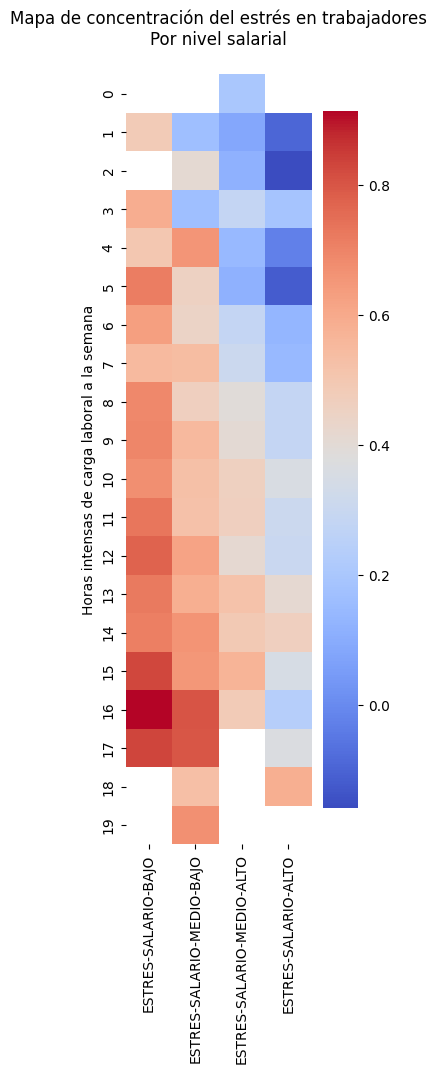

In [706]:
cruce = pandas.DataFrame({
        "CARGA": cargas,
        "SALARIO": pandas.qcut(
            salarios, q=[0, 0.25, 0.5, 0.75, 1], 
            labels=(
                "SALARIO-BAJO", "SALARIO-MEDIO-BAJO", 
                "SALARIO-MEDIO-ALTO", "SALARIO-ALTO"
            )
        ),
        "ESTRES": estreses,
    }).groupby(
        ["CARGA", "SALARIO"], 
        observed=False
    ).mean().unstack()

figure, axis = pyplot.subplots(1, 1, figsize=(3, 10))

seaborn.heatmap(
    cruce.divide(cruce.mean(axis=1).abs() + 1, axis=0),
    cmap="coolwarm",
    ax=axis
)

axis.set_title(
    "Mapa de concentración del estrés en trabajadores\n"
    "Por nivel salarial\n"
)

pyplot.xlabel("")
pyplot.ylabel(
    "Horas intensas de carga laboral a la semana"
)

pyplot.savefig("fig1.png", dpi=300, bbox_inches="tight")

pyplot.show()

In [708]:
cruce.mean(axis=0).unstack()

SALARIO,SALARIO-BAJO,SALARIO-MEDIO-BAJO,SALARIO-MEDIO-ALTO,SALARIO-ALTO
ESTRES,1.400329,1.140653,0.676016,0.514026


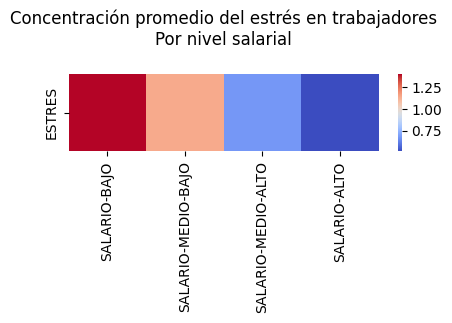

In [685]:
figure, axis = pyplot.subplots(1, 1, figsize=(5, 1))

seaborn.heatmap(
    cruce.mean(axis=0).unstack(),
    cmap="coolwarm",
    ax=axis
)

axis.set_title(
    "Concentración promedio del estrés en trabajadores\n"
    "Por nivel salarial\n"
)

pyplot.xlabel("")

pyplot.savefig("fig2.png", dpi=300, bbox_inches="tight")

pyplot.show()

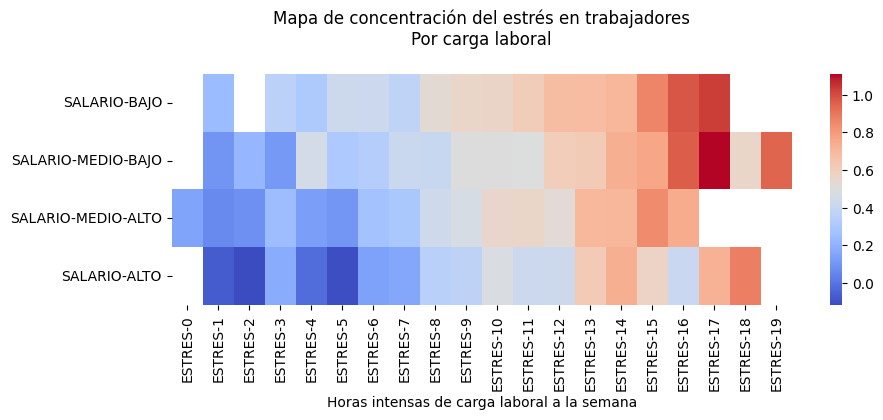

In [ ]:
cruce = pandas.DataFrame({
        "CARGA": cargas,
        "SALARIO": pandas.qcut(
            salarios, q=[0, 0.25, 0.5, 0.75, 1], 
            labels=(
                "SALARIO-BAJO", "SALARIO-MEDIO-BAJO", 
                "SALARIO-MEDIO-ALTO", "SALARIO-ALTO"
            )
        ),
        "ESTRES": estreses,
    }).groupby(
        ["SALARIO", "CARGA"], 
        observed=False
    ).mean().unstack()

figure, axis = pyplot.subplots(1, 1, figsize=(10, 3))

seaborn.heatmap(
    cruce.divide(cruce.mean(axis=1).abs() + 1, axis=0),
    cmap="coolwarm",
    ax=axis
)

axis.set_title(
    "Mapa de concentración del estrés en trabajadores\n"
    "Por carga laboral\n"
)

pyplot.xlabel(
    "Horas intensas de carga laboral "
    "a la semana"
)
pyplot.ylabel("")

pyplot.savefig("fig3.png", dpi=300, bbox_inches="tight")

pyplot.show()

In [573]:
cruce.mean(axis=0).unstack()

CARGA,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
ESTRES,0.25,0.191875,0.141667,0.440521,0.47025,0.413691,0.594201,0.627501,0.842918,0.936336,1.021786,1.025118,1.11603,1.27183,1.391115,1.496597,1.570417,1.985556,1.265,2.02


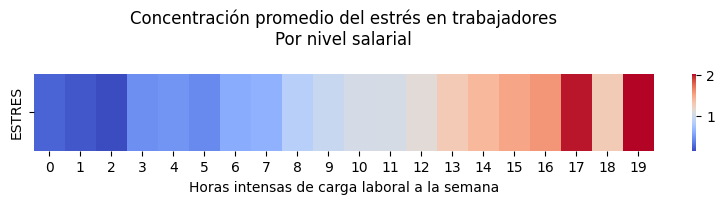

In [ ]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 1))

seaborn.heatmap(
    cruce.mean(axis=0).unstack(),
    cmap="coolwarm",
    ax=axis
)

axis.set_title(
    "Concentración promedio del estrés en "
    "trabajadores\n"
    "Por nivel salarial\n"
)

pyplot.xlabel("Horas intensas de carga laboral a la semana")

pyplot.savefig("fig4.png", dpi=300, bbox_inches="tight")

pyplot.show()

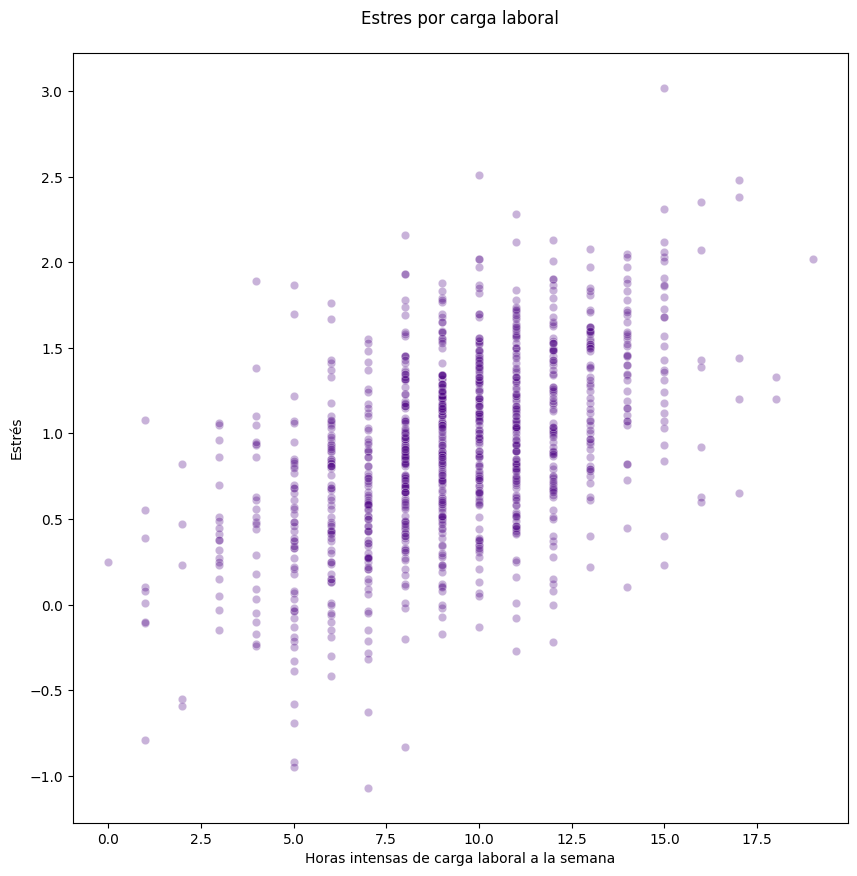

In [ ]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 10))

seaborn.scatterplot(
    x=cargas, 
    y=estreses, 
    color="indigo", 
    alpha=0.3, 
    ax=axis
)

axis.set_title(
    "Estres por carga laboral\n"
)

pyplot.xlabel(
    "Horas intensas de carga laboral "
    "a la semana"
)
pyplot.ylabel("Estrés")

pyplot.savefig("fig5.png", dpi=300, bbox_inches="tight")

pyplot.show()

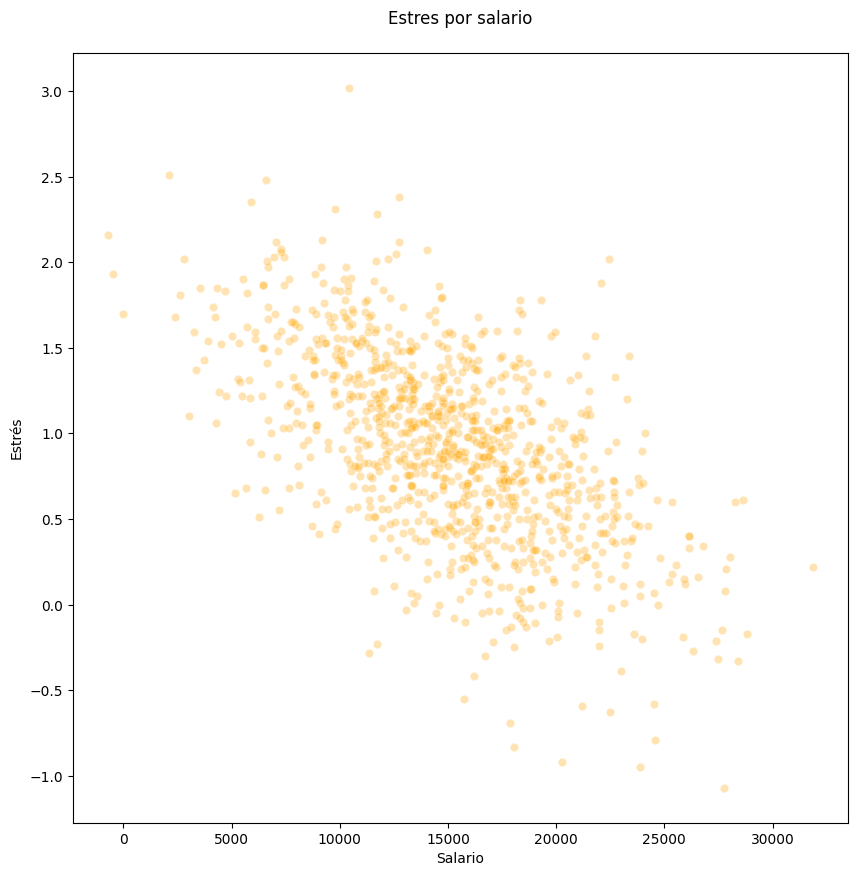

In [ ]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 10))

seaborn.scatterplot(
    x=salarios,
    y=estreses,
    color="orange",
    alpha=0.3,
    ax=axis
)

axis.set_title(
    "Estres por salario\n"
)

pyplot.xlabel("Salario")
pyplot.ylabel("Estrés")

pyplot.savefig("fig6.png", dpi=300, bbox_inches="tight")

pyplot.show()

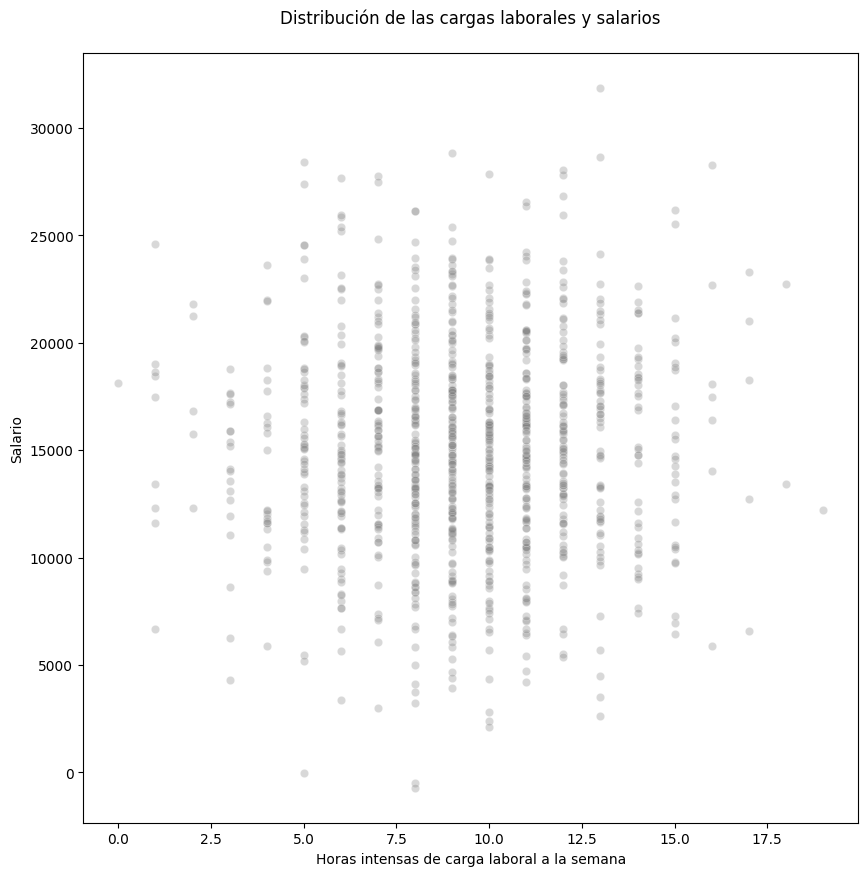

In [ ]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 10))

seaborn.scatterplot(
    x=cargas, 
    y=salarios, 
    color="gray", 
    alpha=0.3, 
    ax=axis
)

axis.set_title(
    "Distribución de las cargas laborales y salarios\n"
)

pyplot.xlabel(
    "Horas intensas de carga laboral "
    "a la semana"
)
pyplot.ylabel("Salario")

pyplot.savefig("fig7.png", dpi=300, bbox_inches="tight")

pyplot.show()

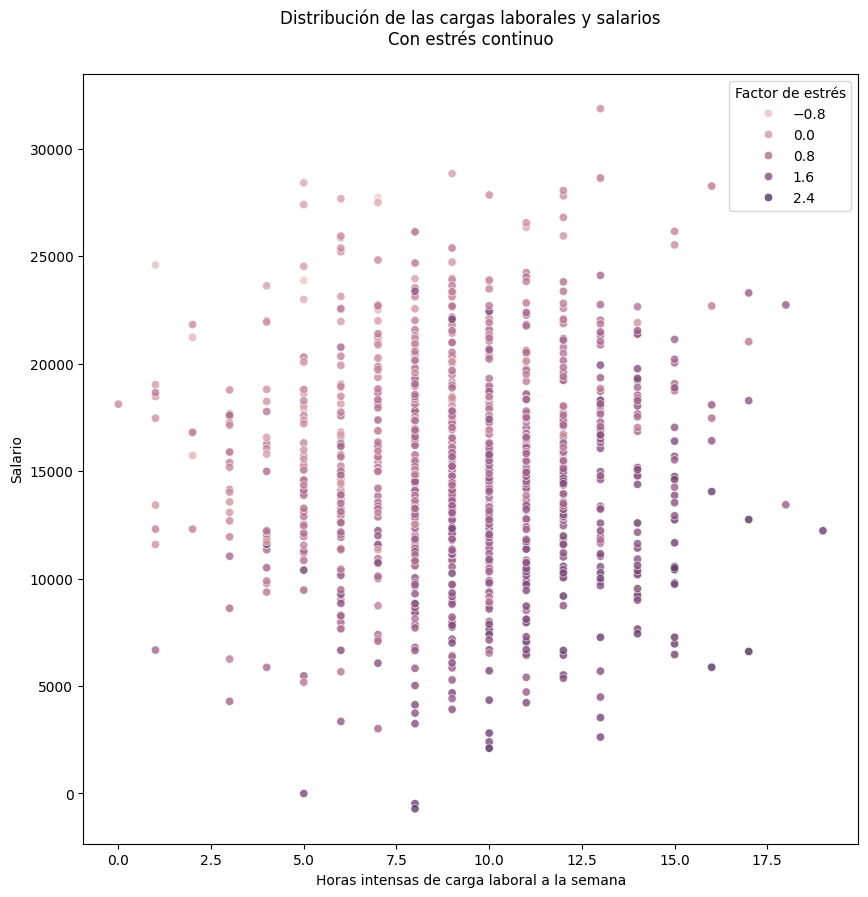

In [724]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 10))

seaborn.scatterplot(
    x=cargas, 
    y=salarios, 
    hue=estreses, 
    alpha=0.8,
    ax=axis
)

axis.set_title(
    "Distribución de las cargas laborales y salarios\n"
    "Con estrés continuo\n",
)

axis.legend(title="Factor de estrés")

pyplot.xlabel(
    "Horas intensas de carga laboral "
    "a la semana"
)
pyplot.ylabel("Salario")

pyplot.savefig("fig8.png", dpi=300, bbox_inches="tight")

pyplot.show()

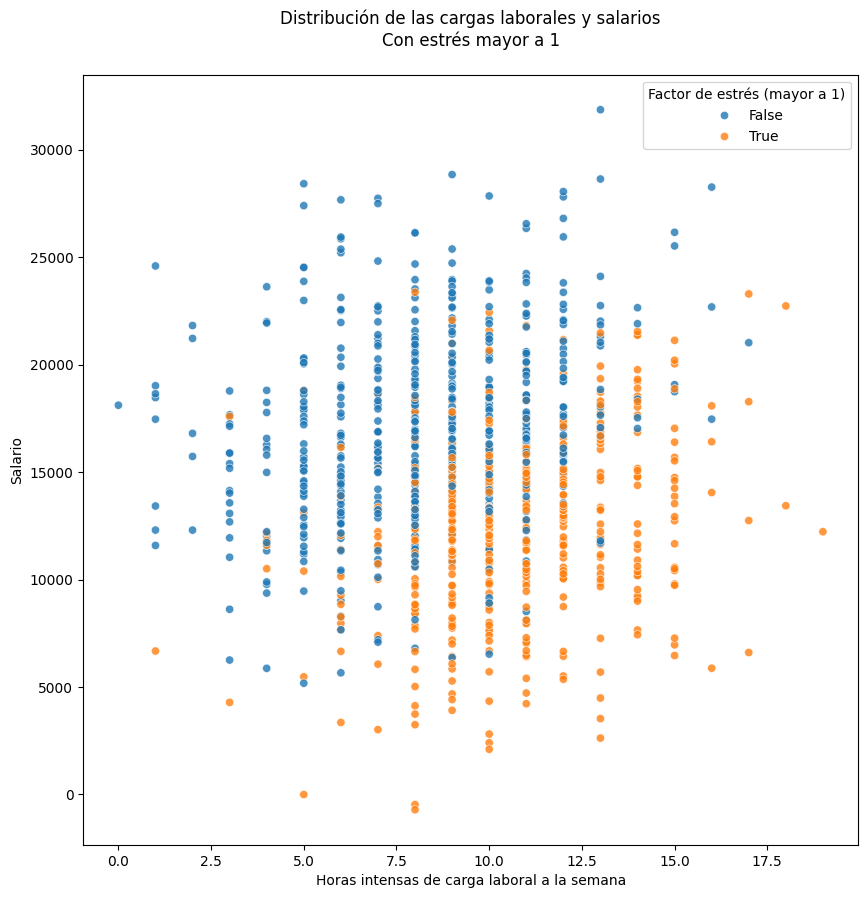

In [ ]:
figure, axis = pyplot.subplots(1, 1, figsize=(10, 10))

seaborn.scatterplot(
    x=cargas,
    y=salarios,
    hue=estreses > 1, 
    alpha=0.8,
    ax=axis
)

axis.set_title(
    "Distribución de las cargas laborales y salarios\n"
    "Con estrés mayor a 1\n",
)

axis.legend(title="Factor de estrés (mayor a 1)")

pyplot.xlabel(
    "Horas intensas de carga laboral "
    "a la semana"
)
pyplot.ylabel("Salario")

pyplot.savefig("fig9.png", dpi=300, bbox_inches="tight")

pyplot.show()

In [696]:
pandas.DataFrame({
    "CARGA": cargas,
    "SALARIO": salarios,
    "ESTRES": estreses,
}).to_csv("../../conjuntos/estres.csv")